# 04 · Is this a verified purchase? (binary classification)

**Use case.** Trust & safety wants to flag reviews that read like unverified ones — a probability per review that can rank the whole table and set a threshold.

**Model / lane:** relational GNN — default GraphSAGE (*Baseline*), text embeddings

**What you will learn**
1. Define a **binary** task on `review.verified`
2. AUROC, PR-AUC (vs the class prior), precision / recall / F1 — what each floor means
3. The Model tab: the ROC curve and the confusion matrix as images
4. Rank every review both ways; score a batch; look at the probability distribution
5. Choose a threshold: what the confusion matrix says about the default 0.5

**What this costs.** one GPU training run (a few minutes on `g4dn.2xlarge`; the API reserves the estimate — about 8,700 credits on the Team plan — and refunds the unused minutes, so a 90-second run ends up costing a few hundred), plus 50 credits per on-demand prediction. A re-run that finds the finished model pays only for its predictions.

> Every cell below ran for real against `api.langsat.ai` — the outputs are what the API returned. Re-running is safe:
> projects are found by name and reused, and a finished model is not retrained.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, print_schema, train_or_reuse, credits_used, save_metrics, show, fig, metrics_table, project_models
from langsat import viz
import pandas as pd

ls = connect()

signed in as team@langsat.ai · tier team · key 'TEST-SDK-4' with 20 scopes


In [2]:
p = get_or_create_project(ls, "verified", kind="data_science")
before = credits_used(ls)

reusing project 28106708-9ec0-48e4-b292-d600b9bc2ed8 (amazon-reviews-verified, status=ready)
files already uploaded: ['customer.csv', 'product.csv', 'review.csv'] — skipping the upload
schema already detected — skipping
project ready: status=ready · type=data_science · files=['customer.csv', 'product.csv', 'review.csv']


*Data.* The same three CSVs as chapter 01, uploaded the same way (`projects.create` → `sources.upload` → `schema.detect()`); a `data_science` project skips the clean step because the training pipeline cleans. `get_or_create_project` runs those calls and prints what it skips on a re-run — the step-by-step version with outputs is in [01](../01_setup_and_explore/).

## Define the task, train

The task is one sentence. `train_or_reuse` prints the config Langsat derived (entity table, target, which text columns get embedded), the estimate, then polls the run and reuses a finished model on re-runs. 

In [3]:
model = train_or_reuse(p, "Predict whether a review is a verified purchase, from the review text, the summary, the rating and the product",
                       task_type="supervised", subtask_type="binary_classification", enable_text_embedding=True)
metrics = model["metrics"]
show(metrics, keys=("auroc", "pr_auc", "pr_auc_baseline", "acc", "precision", "recall", "f1"))

reusing model 61b6e350-ea4c-4219-a694-00835a452fd5 (Baseline, trained 2026-09-15T09:02:43.001054+00:00)
  f1                     0.7783
  acc                    0.667
  auroc                  0.6281
  pr_auc                 0.7831
  recall                 0.8453
  precision              0.7212
  pr_auc_baseline        0.6915


Read the two AUCs against their floors: AUROC's floor is 0.5 whatever the class balance; PR-AUC's floor is the **positive rate** (71% of reviews are verified), so `pr_auc / pr_auc_baseline` is the lift.

In [4]:
print(f"AUROC {metrics['auroc']:.3f} (random 0.500) · PR-AUC {metrics['pr_auc']:.3f} vs prior {metrics['pr_auc_baseline']:.3f} → lift ×{metrics['pr_auc']/metrics['pr_auc_baseline']:.2f} · F1 {metrics['f1']:.3f}")

AUROC 0.628 (random 0.500) · PR-AUC 0.783 vs prior 0.692 → lift ×1.13 · F1 0.778


## The Model tab, as images

After training the app builds a **Model** tab: overview, feature importance, training curves and the task-specific
cards. It is a normal dashboard tab whose widgets carry Plotly JSON, so `viz.model_dashboard(p)` draws exactly what the
app shows — and `viz.model_cards(p)` lets you pick one card. The Model Overview table carries numbers the API's
`metrics` dict does not (they live only in the trained model's metadata).

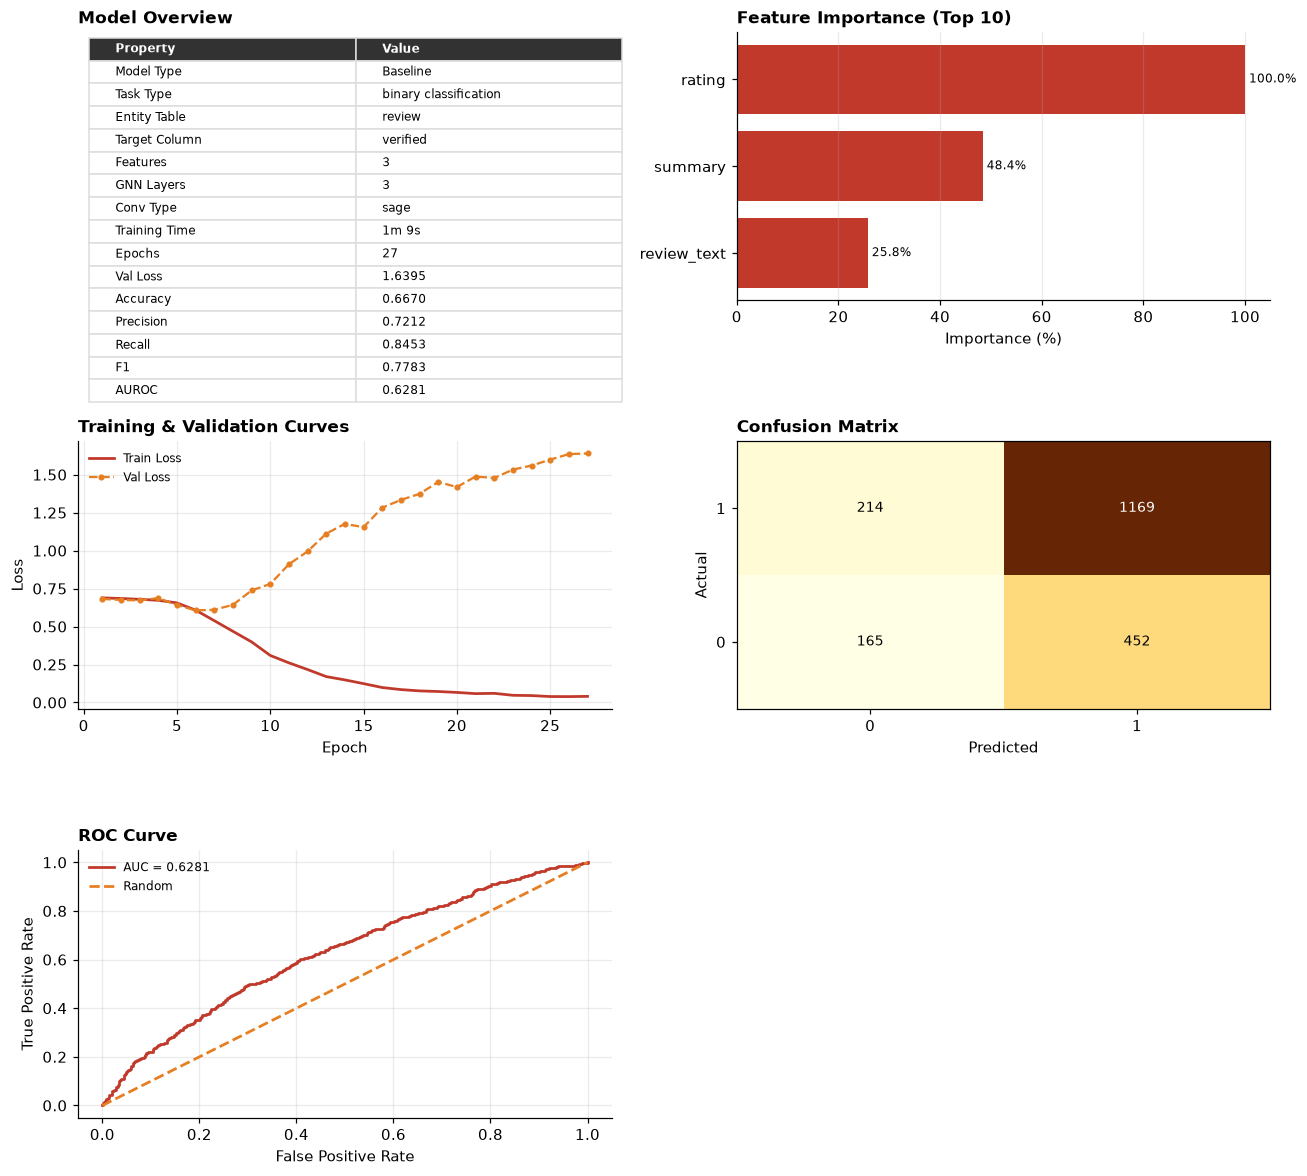

In [5]:
fig(viz.model_dashboard(p, cols=2))

The confusion matrix at the default 0.5 cut: with 71% positives the model leans toward *verified*. If the team wants fewer false alarms they raise the threshold and rank with `order="asc"` instead — the ROC curve is the menu of trade-offs.

In [6]:
cm = viz.model_cards(p)["Confusion Matrix"]["plotly"]["data"][0]
pd.DataFrame(cm["z"], index=[f"actual {y}" for y in cm["y"]], columns=[f"pred {x}" for x in cm["x"]])

,pred 0,pred 1
actual 1,214,1169
actual 0,165,452


## Rank every review, score a batch

`predict.top` orders by the positive-class probability; `predict_batch` scores a list of ids in one call (50 credits each). The histogram of scored probabilities shows how decisive the model is.

In [7]:
top = ls.predict.top(model["model_id"], n=10)
least = ls.predict.top(model["model_id"], n=10, order="asc")
print("most likely verified :", [(r["entity_id"], round(r["score"], 3)) for r in top["ranking"][:5]])
print("least likely verified:", [(r["entity_id"], round(r["score"], 3)) for r in least["ranking"][:5]])

most likely verified : [(3997, 0.922), (723, 0.921), (628, 0.92), (8786, 0.919), (2517, 0.919)]
least likely verified: [(8105, 0.055), (6857, 0.057), (1843, 0.058), (2700, 0.059), (6749, 0.059)]


20 of 20 scored


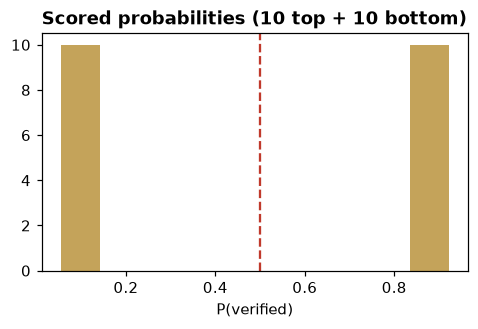

In [8]:
ids = [r["entity_id"] for r in top["ranking"][:10]] + [r["entity_id"] for r in least["ranking"][:10]]
batch = ls.predict.predict_batch(model_id=model["model_id"], entity_ids=ids)
probs = [pr.get("probability") for pr in batch["predictions"] if pr.get("probability") is not None]
print(batch["succeeded"], "of", batch["total"], "scored")
import matplotlib.pyplot as plt
f, ax = plt.subplots(figsize=(5, 2.8)); ax.hist(probs, bins=10, color="#c4a35a"); ax.axvline(0.5, color="#c0392b", ls="--")
ax.set_xlabel("P(verified)"); ax.set_title("Scored probabilities (10 top + 10 bottom)", loc="left", fontweight="bold"); fig(f)

In [9]:
charged = credits_used(ls) - before
save_metrics(".", {"notebook": "04_verified_purchase_binary", "task": "binary · review.verified", "model": model.get("model_type"),
                   "project_id": p.id, "model_id": model["model_id"], "training_duration_sec": model.get("training_duration_sec"),
                   "credits_charged_this_run": charged,
                   "headline": {"auroc": metrics.get("auroc"), "pr_auc": metrics.get("pr_auc"), "f1": metrics.get("f1"), "accuracy": metrics.get("acc")},
                   "baseline": {"auroc": 0.5, "pr_auc": metrics.get("pr_auc_baseline")}})

wrote results/metrics.json


PosixPath('results/metrics.json')

## Where to go next

- [08 · Predict API & monitoring](../08_predict_api_and_monitoring/) — this model behind an application
- [05 · Product clustering](../05_product_clustering/) — no labels at all